In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer



In [2]:
df=pd.read_csv(r"D:\ML\datasets\retitanicdata.csv",usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
df.dropna(inplace=True)

In [10]:
df.shape

(714, 3)

In [12]:
x=df.iloc [:,1:]
y=df.iloc[:,0]

0      0
1      1
2      1
3      1
4      0
      ..
885    0
886    0
887    1
889    1
890    0
Name: Survived, Length: 714, dtype: int64

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,train_size=0.8)

In [16]:
x_train.head(3)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000


In [18]:
clf=DecisionTreeClassifier()

In [19]:
clf.fit(x_train,y_train)
ypred=clf.predict(x_test)

In [20]:
accuracy_score(y_test,ypred)

0.6223776223776224

In [23]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

0.6303403755868543

## Applying Binning and checking 

In [26]:
kbin_age=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare=KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [27]:
trf=ColumnTransformer(
    [
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ]
)

In [28]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

c:\Users\Aditya Sarapure\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
c:\Users\Aditya Sarapure\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [36]:
print("total bins:",trf.named_transformers_['first'].n_bins_)
print("Intervals:",trf.named_transformers_['first'].bin_edges_)

total bins: [10]
Intervals: [array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
        50.  , 80.  ])                                                ]


In [35]:
print("total bins:",trf.named_transformers_['second'].n_bins_)
print("Intervals:",trf.named_transformers_['second'].bin_edges_)

total bins: [10]
Intervals: [array([  0.    ,   7.75  ,   7.8958,   9.225 ,  13.    ,  15.75  ,
         26.    ,  29.125 ,  51.4792,  82.1708, 512.3292])         ]


In [38]:
output=pd.DataFrame(
    {
        'age':x_train['Age'],
        'age_trf':x_train_trf[:,0],
        'fare':x_train['Fare'],
        'fare_trf':x_train_trf[:,1]
    }
)

In [40]:
output['age_label']=pd.cut(x=x_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels']=pd.cut(x=x_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [41]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_label,fare_labels
588,22.0,3.0,8.0500,2.0,"(19.0, 22.0]","(7.896, 9.225]"
146,27.0,4.0,7.7958,1.0,"(25.0, 28.5]","(7.75, 7.896]"
315,26.0,4.0,7.8542,1.0,"(25.0, 28.5]","(7.75, 7.896]"
44,19.0,2.0,7.8792,1.0,"(14.0, 19.0]","(7.75, 7.896]"
145,19.0,2.0,36.7500,7.0,"(14.0, 19.0]","(29.125, 51.479]"


In [46]:
clf=DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
ypred2=clf.predict(x_test_trf)

In [47]:
y_test.shape

(143,)

In [48]:
ypred2.shape

(143,)

In [49]:
accuracy_score(y_test,ypred2)

0.6223776223776224

In [57]:
def discretize(bins,strategy):
    kbin_age=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare=KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf=ColumnTransformer(
        [
            ('first',kbin_age,[0]),
            ('second',kbin_fare,[1])
        ]
    )

    x_trf=trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,0],color='red')
    plt.title('After')

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")
    
    plt.subplot(122)
    plt.hist(x_trf[:,1],color='red')
    plt.title('Fare')
    
    plt.show()
    





0.6359154929577464


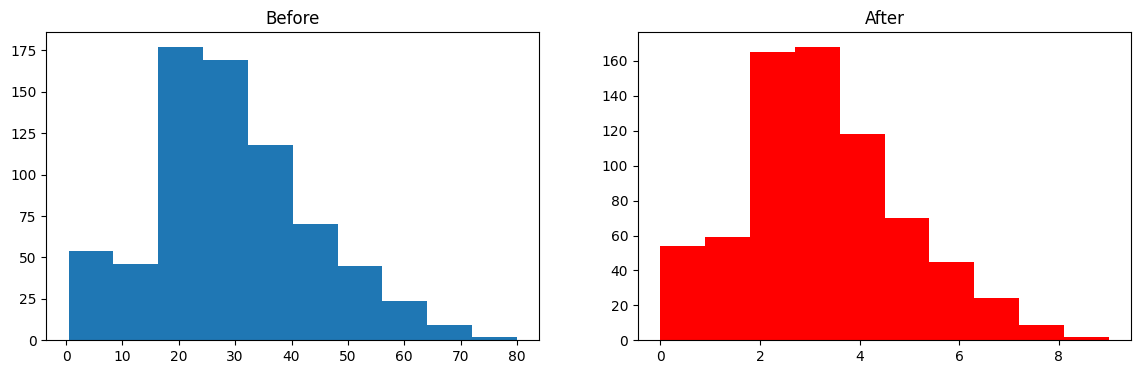

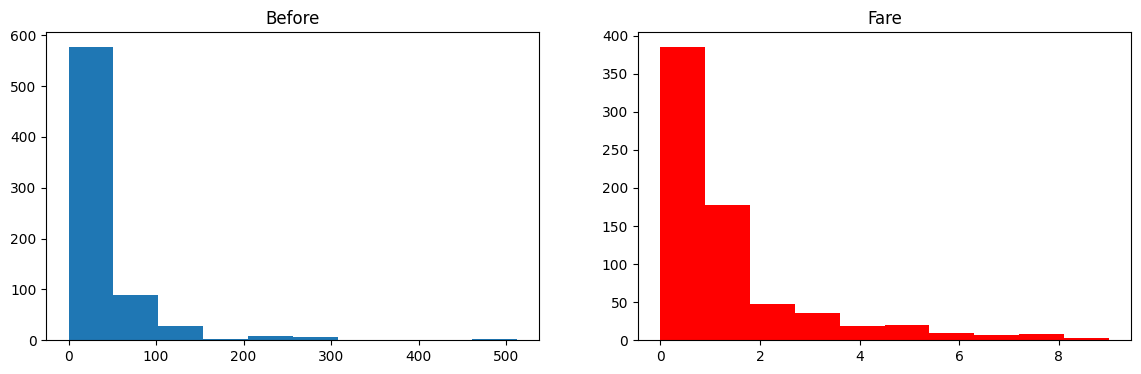

In [64]:
discretize(10,'kmeans')